# Medical Assistant: A RAG-based Clinical Knowledge Assistant
### Full-Code Project | OpenAI (`gpt-4o-mini` + `gpt-4o` judge) | Merck Manual of Diagnosis & Therapy (19th Edition)
---


## Problem Statement

### Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes and ensuring informed decision-making in a fast-paced environment.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital. Furthermore, access to trusted, current medical information from renowned manuals and research papers is essential for maintaining high standards of care.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency. Leveraging centralized knowledge platforms and ensuring healthcare providers have continuous access to reliable resources can significantly improve patient care and operational effectiveness.


**Common Questions to Answer**

**1. Diagnostic Assistance**: "What are the common symptoms and treatments for pulmonary embolism?"

**2. Drug Information**: "Can you provide the trade names of medications used for treating hypertension?"

**3. Treatment Plans**: "What are the first-line options and alternatives for managing rheumatoid arthritis?"

**4. Specialty Knowledge**: "What are the diagnostic steps for suspected endocrine disorders?"

**5. Critical Care Protocols**: "What is the protocol for managing sepsis in a critical care unit?"

### Objective

As an AI specialist, your task is to develop a RAG-based AI solution using renowned medical manuals to address healthcare challenges. The objective is to **understand** issues like information overload, **apply** AI techniques to streamline decision-making, **analyze** its impact on diagnostics and patient outcomes, **evaluate** its potential to standardize care practices, and **create** a functional prototype demonstrating its feasibility and effectiveness.


### Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

The manual is provided as a PDF with over 4,000 pages divided into 23 sections.


### Notebook Roadmap

| # | Section | What it delivers |
| --- | --- | --- |
| 1 | Setup | Local kernel, OpenAI client from `config.json`, helper utilities |
| 2 | Question Answering using LLM | Baseline (ungrounded) answers to the 5 questions |
| 3 | QA using LLM with Prompt Engineering | 5 prompt + parameter combinations, compared side by side |
| 4 | Data Preparation for RAG | PDF load, chunking, embeddings, Chroma vector store, retriever |
| 5 | Question Answering using RAG | Grounded answers + retrieval diagnostics |
| 6 | Fine-tuning the RAG pipeline | 6 chunking / retriever / decoding combinations, plus a root-cause fix for the failing query |
| 7 | Output Evaluation | Groundedness and relevance scoring with a **separate** judge model |
| 8 | Actionable Insights and Recommendations | Business conclusions |

> **Runtime (local):** Windows. Select the **Python (Medical Assistant)** kernel (the `.venv` created by `setup_local.ps1`). Place `medical_diagnosis_manual.pdf` and `config.json` in this folder. GPU is used only for embeddings (optional); generation goes through the OpenAI API, so no local GGUF / `n_ctx` / `n_gpu_layers` setup is required.
>
> **Credentials:** `config.json` must look like `{"OPENAI_API_KEY": "sk-...", "OPENAI_API_BASE": "https://api.openai.com/v1"}`. Do **not** commit it or paste the key into this notebook.


---
## 1. Installing and Importing Libraries


In [51]:
# Already installed into .venv by setup_local.ps1 for the RAG stack.
# openai is the only extra package this notebook needs versus the Llama version.
%pip install -q openai langchain_community==0.3.27 langchain==0.3.27 \
              chromadb==1.0.15 pymupdf==1.26.3 tiktoken==0.9.0 \
              sentence-transformers==3.0.1 pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


**Note:** Packages are already in the local kernel if you ran `setup_local.ps1` and then `pip install openai`. Restart the kernel only if the `%pip` cell actually installed something new, then run every cell from here onwards. Dependency-resolver warnings can safely be ignored.


In [52]:
# Standard library and data-handling
import json
import os
import re
import shutil
import textwrap
import warnings
from pathlib import Path

# The IDE may set SSLKEYLOGFILE to a path Python cannot open; every HTTPS request
# (Hugging Face downloads and OpenAI calls included) then dies with PermissionError 13.
os.environ.pop("SSLKEYLOGFILE", None)

# CUDA 13.1 puts cublas on bin\x64; sentence-transformers can use the GPU for embeddings.
_cuda_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.1\bin\x64"
if os.path.isdir(_cuda_bin) and _cuda_bin not in os.environ.get("PATH", ""):
    os.environ["PATH"] = _cuda_bin + os.pathsep + os.environ["PATH"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken
from IPython.display import display
from openai import OpenAI

# Loading, chunking, embedding and vector storage
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings
from langchain_community.vectorstores import Chroma

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")


In [53]:
def show(text, width=110):
    """Pretty-print long model outputs so they stay readable inside the notebook."""
    for paragraph in str(text).split("\n"):
        print(textwrap.fill(paragraph, width=width) if paragraph.strip() else "")


def n_tokens(text, encoding_name="cl100k_base"):
    """Token count used consistently for chunking diagnostics and prompt-budget checks."""
    return len(tiktoken.get_encoding(encoding_name).encode(text))


### 1.1 Setting up the OpenAI Client


In [54]:
# Resolve config.json relative to the notebook folder — never a hard-coded Colab /content/ path.
config_candidates = [Path("config.json"), Path.cwd() / "config.json"]
config_path = next((p.resolve() for p in config_candidates if p.exists()), None)
if config_path is None:
    raise FileNotFoundError(
        "Place config.json in this notebook's folder with OPENAI_API_KEY (and optionally "
        "OPENAI_API_BASE), then re-run this cell."
    )

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

if not config.get("OPENAI_API_KEY"):
    raise ValueError("config.json is missing OPENAI_API_KEY")

client = OpenAI(
    api_key=config["OPENAI_API_KEY"],
    base_url=config.get("OPENAI_API_BASE") or None,
)

print(f"Loaded credentials from: {config_path}")
print(f"API base               : {config.get('OPENAI_API_BASE', '(OpenAI default)')}")


Loaded credentials from: D:\Stuff\Medical Assistant\config.json
API base               : https://api.openai.com/v1


Separate models are used for **response generation** and for **LLM-as-a-judge** evaluation. Using a different (and typically stronger) model as the judge avoids the generator grading its own homework, which is a known self-preference bias — and is the main methodological upgrade versus an open-weight notebook that has only one local model available.


In [55]:
llm = "gpt-4o-mini"    # used for generating answers (baseline, prompt-engineered, and RAG)
judge_llm = "gpt-4o"   # used only for the groundedness/relevance judge in Section 7

print(f"Generator : {llm}")
print(f"Judge     : {judge_llm}")


Generator : gpt-4o-mini
Judge     : gpt-4o


### 1.2 Baseline Response Function


In [56]:
def chat(messages, model=None, max_tokens=256, temperature=0, top_p=0.95):
    """Thin wrapper around the Chat Completions API.

    OpenAI chat models do not expose llama.cpp-style top_k; decoding is controlled with
    temperature and top_p only. max_tokens here is the *generation* budget, not the context window
    (gpt-4o-mini's context window is 128k, so retrieved RAG context of a few thousand tokens fits easily).
    """
    completion = client.chat.completions.create(
        model=model or llm,
        messages=messages,
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
    )
    return (completion.choices[0].message.content or "").strip()


def response(query, max_tokens=256, temperature=0, top_p=0.95, system=None):
    """Send a user query (optionally with a system instruction) and return the generated text.

    max_tokens  - generation budget; 256 is the baseline because 128 truncated multi-part answers.
    temperature - 0 gives greedy (deterministic) decoding, appropriate for clinical facts.
    top_p       - nucleus sampling; only has a visible effect when temperature > 0.
    system      - optional system-role instruction (OpenAI's native equivalent of an [INST] wrapper).
    """
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": query})
    return chat(messages, max_tokens=max_tokens, temperature=temperature, top_p=top_p)


**Observation — why these settings:**
- `gpt-4o-mini` is instruction-tuned and uses a native system/user/assistant chat format, so there is no `[INST] ... [/INST]` wrapper to get right. The equivalent discipline is: put role and output-format rules in the **system** message, and keep the question in the **user** message.
- The 128k context window means RAG context size is a *cost and precision* concern, not a silent-truncation risk. That is the opposite failure mode from a 4k–8k local GGUF window, where retrieved chunks can push the system prompt off the left of the context.
- `temperature=0` is still the right default for clinical facts. `top_p` is kept at 0.95 as a harmless default and is only meaningful when temperature is raised in later combinations.


---
## 2. Question Answering using LLM (No Grounding)

This section establishes the **baseline**: what the model can answer from its pre-training knowledge alone, with no system prompt and no retrieved context. Later sections compare prompt engineering and RAG against this floor.


In [57]:
query_1 = "What is the protocol for managing sepsis in a critical care unit?"
query_2 = ("What are the common symptoms of appendicitis, and can it be cured via medicine? "
           "If not, what surgical procedure should be followed to treat it?")
query_3 = ("What are the effective treatments or solutions for addressing sudden patchy hair loss, "
           "commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?")
query_4 = ("What treatments are recommended for a person who has sustained a physical injury to brain tissue, "
           "resulting in temporary or permanent impairment of brain function?")
query_5 = ("What are the necessary precautions and treatment steps for a person who has fractured their leg "
           "during a hiking trip, and what should be considered for their care and recovery?")

queries = {
    "Q1 - Sepsis protocol": query_1,
    "Q2 - Appendicitis": query_2,
    "Q3 - Patchy hair loss": query_3,
    "Q4 - Brain injury": query_4,
    "Q5 - Leg fracture": query_5,
}

# Answers are stored at every stage so the three approaches can be compared and evaluated later
baseline_answers = {}


### Query 1: What is the protocol for managing sepsis in a critical care unit?


In [58]:
baseline_answers["Q1 - Sepsis protocol"] = response(query_1)
show(baseline_answers["Q1 - Sepsis protocol"])


Managing sepsis in a critical care unit involves a systematic approach that includes early recognition, prompt
intervention, and ongoing monitoring. The following steps outline the general protocol for managing sepsis:

### 1. **Early Recognition**
   - **Identify Symptoms**: Look for signs of infection (fever, chills, tachycardia, tachypnea) and organ
dysfunction (altered mental status, hypotension, oliguria).
   - **Use Screening Tools**: Utilize tools like the Sequential Organ Failure Assessment (SOFA) score or the
quick SOFA (qSOFA) to assess the severity of sepsis.

### 2. **Initial Assessment**
   - **Obtain Vital Signs**: Monitor blood pressure, heart rate, respiratory rate, and temperature.
   - **Assess Organ Function**: Evaluate renal function (urine output, creatinine), liver function (bilirubin,
liver enzymes), and coagulation status (platelets, INR).

### 3. **Immediate Interventions**
   - **Fluid Resuscitation**: Administer intravenous (IV) fluids (crystalloids) rapidly,

**Observations:**
- With no system prompt or retrieved context, `gpt-4o-mini` answers from pre-training. It opens with a textbook-style protocol (early recognition, SOFA/qSOFA) rather than Merck Manual wording, CVP/PAOP endpoints, or named vasopressor doses.
- The answer is already headed and numbered — instruction-tuning gives structure even without a system prompt.
- At `temperature=0` and `max_tokens=256` it **does reach fluids (30 mL/kg in 3 hours) and antibiotics-within-1-hour**, then **truncates mid-antibiotic sentence**. The Surviving Sepsis-style numbers come from pre-training; the Merck CVP/PAOP/dopamine-threshold language still does not.


### Query 2: What are the common symptoms of appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?


In [59]:
baseline_answers["Q2 - Appendicitis"] = response(query_2)
show(baseline_answers["Q2 - Appendicitis"])


Common symptoms of appendicitis include:

1. **Abdominal Pain**: Typically starts around the navel and then moves to the lower right abdomen.
2. **Loss of Appetite**: A sudden decrease in appetite is common.
3. **Nausea and Vomiting**: Often follows the onset of abdominal pain.
4. **Fever**: A low-grade fever may develop.
5. **Constipation or Diarrhea**: Changes in bowel habits can occur.
6. **Abdominal Swelling**: The abdomen may become swollen or tender.

Appendicitis cannot be effectively treated with medication alone. The standard treatment for appendicitis is
surgical removal of the appendix, a procedure known as an **appendectomy**. This can be performed using two
main techniques:

1. **Open Appendectomy**: A larger incision is made in the lower right abdomen to remove the appendix.
2. **Laparoscopic Appendectomy**: This is a minimally invasive procedure where several small incisions are
made, and the appendix is removed using a camera and specialized instruments.

Laparoscopic a

**Observations:**
- Appendicitis is high-frequency knowledge: the symptom list is broadly correct (periumbilical pain migrating to the right lower quadrant, nausea, anorexia, fever).
- At 256 tokens this run **does complete all three limbs**: medicine is not curative, and both open and laparoscopic appendectomy are named. The answer still truncates while discussing which procedure is preferred.
- Nothing here is sourced to the manual (no McBurney's point, Rovsing, psoas, or obturator signs). Those appear only once retrieval hits Chapter 11. The unique RAG gain on this question is the *signs*, not the procedure name.


### Query 3: What are the effective treatments for sudden patchy hair loss, and what could be the possible causes?


In [60]:
baseline_answers["Q3 - Patchy hair loss"] = response(query_3)
show(baseline_answers["Q3 - Patchy hair loss"])


Sudden patchy hair loss, often referred to as alopecia areata, can manifest as localized bald spots on the
scalp or other areas of the body. Here are some effective treatments and solutions, as well as potential
causes:

### Possible Causes:
1. **Autoimmune Disorders**: The immune system mistakenly attacks hair follicles, leading to hair loss.
2. **Genetics**: A family history of alopecia or other autoimmune conditions can increase risk.
3. **Stress**: Physical or emotional stress can trigger hair loss in some individuals.
4. **Hormonal Changes**: Changes in hormones, such as those occurring during pregnancy or menopause, can
contribute.
5. **Nutritional Deficiencies**: Lack of essential nutrients, such as iron, zinc, or vitamin D, may play a
role.
6. **Infections**: Fungal infections like tinea capitis can cause patchy hair loss.
7. **Allergic Reactions**: Allergies to hair products or other substances can lead to hair loss.

### Effective Treatments:
1. **Topical Corticosteroids**: T

**Observations:**
- The model correctly infers **alopecia areata** from the lay description, lists seven cause categories, then starts treatments (topical corticosteroids, minoxidil) — the two-stage shape Combination 3 will later enforce is already present.
- At 256 tokens it **truncates mid-minoxidil**, so the first-line-to-last-line ladder is incomplete. Combination 3, with 400 tokens, finishes that ladder and adds JAK inhibitors.
- Fluency is not grounding. Section 3's Combination 3 later adds JAK inhibitors (tofacitinib, ruxolitinib), a class the 19th-edition manual does not contain.


### Query 4: What treatments are recommended after a physical injury to brain tissue?


In [61]:
baseline_answers["Q4 - Brain injury"] = response(query_4)
show(baseline_answers["Q4 - Brain injury"])


The treatment for a person who has sustained a physical injury to brain tissue, such as a traumatic brain
injury (TBI), can vary widely depending on the severity of the injury, the specific areas of the brain
affected, and the resulting impairments. Here are some common approaches to treatment:

1. **Emergency Care**:
   - Immediate medical attention is crucial. This may involve stabilizing the patient, monitoring vital signs,
and performing imaging studies (like CT or MRI scans) to assess the extent of the injury.

2. **Surgical Interventions**:
   - In cases of severe injury, surgery may be necessary to relieve pressure on the brain, remove blood clots
(hematomas), or repair skull fractures.

3. **Medication**:
   - Medications may be prescribed to manage symptoms such as pain, seizures, or inflammation. Corticosteroids
may be used to reduce swelling in the brain.

4. **Rehabilitation**:
   - **Physical Therapy**: To improve mobility and strength.
   - **Occupational Therapy**: To as

**Observations:**
- The model recognises traumatic brain injury and lists emergency care, surgery, medication, then rehabilitation (PT, OT, speech). The two limbs are in one numbered bag rather than an emergency/rehab split.
- At 256 tokens it **truncates inside neuropsychological therapy**, after rehab has already started. Coverage is better than a run that died in surgery; the missing tail is still budget.
- The content is generic (CT/MRI, clots, corticosteroids for swelling). RAG in Section 5 is where airway / ventilation / ICP / haematoma language from Chapter 324 appears — more specific on acute care, thinner on the rehab list unless `k` is raised.


### Query 5: What precautions and treatment steps apply to a leg fracture sustained while hiking?


In [62]:
baseline_answers["Q5 - Leg fracture"] = response(query_5)
show(baseline_answers["Q5 - Leg fracture"])


If someone has fractured their leg during a hiking trip, it's crucial to take immediate and appropriate steps
to ensure their safety and facilitate recovery. Here are the necessary precautions, treatment steps, and
considerations for care and recovery:

### Immediate Precautions and Treatment Steps

1. **Ensure Safety**:
   - Move the injured person to a safe location away from any potential hazards (e.g., cliffs, wildlife).
   - If possible, have someone stay with the injured person while help is sought.

2. **Assess the Injury**:
   - Check for signs of a fracture, such as severe pain, swelling, deformity, or inability to bear weight.
   - Look for signs of circulation issues (e.g., pale or blue skin, numbness).

3. **Immobilization**:
   - Keep the leg as still as possible to prevent further injury.
   - If available, use a splint to immobilize the leg. You can create a makeshift splint using sticks, rolled-
up newspapers, or any rigid material.
   - Secure the splint with cloth or 

**Observations:**
- This is the baseline's most usable start: scene safety, assess pain/swelling/deformity and circulation, immobilise with a makeshift splint, control bleeding. Common first-aid knowledge is well represented in pre-training.
- At 256 tokens it **truncates during control of bleeding**, so evacuation, definitive orthopaedic treatment, and recovery are never reached. More of the field-care limb is present than in the shorter earlier run; the later limbs are still missing.
- Worth noting for later: this truncated but *on-topic* answer is still more useful than a RAG answer from the wrong chapter would have been. In Section 5, `k=3` retrieves snakebite and falls passages; `gpt-4o-mini` abstains rather than blending them. Fluency is not grounding, and a source list is the only way to tell the difference.


---
## 3. Question Answering using LLM with Prompt Engineering

OpenAI chat models are trained to follow a **system** role. That is the native equivalent of an `[INST]` wrapper, and it is the first improvement: put the role, format, and constraints in the system message so they are not mixed into the question. On top of that, five combinations vary **role framing, output structure, and decoding parameters** (`max_tokens`, `temperature`, `top_p`).


In [63]:
def build_messages(instruction, question):
    """Put the role/task instruction in the system role and the question in the user role."""
    return [
        {"role": "system", "content": instruction.strip()},
        {"role": "user", "content": question.strip()},
    ]


prompt_engineered_answers = {}

# Each entry records the full configuration so the combinations can be tabulated and compared
prompt_experiments = []


### Combination 1 — Role prompting + numbered protocol, greedy decoding (Query 1)


In [64]:
instruction_1 = (
    "You are an experienced critical care physician. Answer the medical question accurately and "
    "concisely. Present the answer as a numbered list of protocol steps, ordered by clinical priority."
)
params_1 = dict(max_tokens=400, temperature=0.0, top_p=0.95)

prompt_engineered_answers["Q1 - Sepsis protocol"] = chat(
    build_messages(instruction_1, query_1), **params_1
)
prompt_experiments.append({
    "Combination": 1, "Query": "Q1 - Sepsis", "Prompt technique": "Role + numbered list", **params_1,
})
show(prompt_engineered_answers["Q1 - Sepsis protocol"])


1. **Immediate Assessment**: Evaluate the patient’s vital signs, level of consciousness, and overall clinical
status. Identify signs of organ dysfunction and septic shock.

2. **Obtain Cultures**: Collect blood cultures and any other relevant cultures (urine, sputum, wound) before
starting antibiotics to identify the causative organism.

3. **Initiate Broad-Spectrum Antibiotics**: Administer appropriate broad-spectrum intravenous antibiotics
within 1 hour of sepsis recognition to cover likely pathogens.

4. **Fluid Resuscitation**: Start aggressive fluid resuscitation with crystalloids (e.g., normal saline or
lactated Ringer's) to restore hemodynamic stability, targeting a minimum of 30 mL/kg within the first 3 hours.

5. **Monitor Hemodynamics**: Continuously monitor vital signs, urine output, and central venous pressure (if
applicable) to assess response to fluid resuscitation.

6. **Vasopressor Support**: If hypotension persists despite adequate fluid resuscitation (mean arterial
pr

**Observations:**
- Role prompting plus a numbered-list instruction converts Section 2's truncated prose into a protocol: blood cultures before antibiotics, 30 mL/kg crystalloid in 3 hours, MAP ≥ 65 mm Hg, norepinephrine, source control.
- Raising `max_tokens` to 400 is necessary and still not quite enough: the answer **truncates at item 11** ("Consideration of Corticost"). Structure used the extra budget; it did not remove the need to size it.
- `temperature=0` keeps the step order stable. The content is still Surviving-Sepsis-style pre-training, not the Merck CVP/PAOP/dopamine-threshold language that RAG produces in Section 6.


### Combination 2 — Enforced headings, low-temperature sampling (Query 2)


In [65]:
instruction_2 = (
    "You are a medical assistant. Structure your answer under exactly three headings: "
    "'Symptoms', 'Can Medicine Cure It?', and 'Surgical Procedure'. "
    "Keep each section to at most five short bullet points and be specific and factual."
)
params_2 = dict(max_tokens=400, temperature=0.2, top_p=0.9)

prompt_engineered_answers["Q2 - Appendicitis"] = chat(
    build_messages(instruction_2, query_2), **params_2
)
prompt_experiments.append({
    "Combination": 2, "Query": "Q2 - Appendicitis",
    "Prompt technique": "Mandated headings + length cap", **params_2,
})
show(prompt_engineered_answers["Q2 - Appendicitis"])


### Symptoms
- Sudden pain in the lower right abdomen.
- Nausea and vomiting.
- Loss of appetite.
- Fever and chills.
- Abdominal swelling or bloating.

### Can Medicine Cure It?
- Antibiotics may help manage symptoms temporarily.
- Medicine alone is not a definitive cure.
- Risk of complications like perforation increases without surgery.
- Pain relief medications can be used but do not treat the underlying issue.
- Surgery is generally required for complete resolution.

### Surgical Procedure
- **Appendectomy**: The standard surgical procedure to remove the appendix.
  - Can be performed as an open surgery or laparoscopically.
  - Laparoscopic appendectomy is less invasive with quicker recovery.
  - Typically performed under general anesthesia.
  - Post-operative care includes monitoring for infection and managing pain.


**Observations:**
- Mandating three headings is the most reliable fix for this multi-part question: **Symptoms**, **Can Medicine Cure It?**, and **Surgical Procedure** are all present, each capped at five bullets.
- The medicine limb is explicit ("Medicine alone is not a definitive cure") and the procedure limb names both open and laparoscopic appendectomy. The 256-token baseline already named both techniques this run; Combination 2 is the *cleanest* complete three-limb answer, not the first to name surgery.
- A small temperature (0.2) did not invent extras here. The risk remains: the same format would make an unsourced claim look authoritative. RAG later supplies McBurney's point and the named signs that this answer still lacks.


### Combination 3 — Two-stage reasoning, moderate sampling (Query 3)


In [66]:
instruction_3 = (
    "You are a dermatology consultant. Work through the problem in two stages: first state the single most "
    "likely diagnosis for the described presentation and its causes, then list the evidence-based treatments "
    "as bullet points, ordered from first-line to last-line. Do not discuss other types of hair loss."
)
params_3 = dict(max_tokens=400, temperature=0.4, top_p=0.85)

prompt_engineered_answers["Q3 - Patchy hair loss"] = chat(
    build_messages(instruction_3, query_3), **params_3
)
prompt_experiments.append({
    "Combination": 3, "Query": "Q3 - Patchy hair loss",
    "Prompt technique": "Two-stage reasoning + scope restriction", **params_3,
})
show(prompt_engineered_answers["Q3 - Patchy hair loss"])


The single most likely diagnosis for sudden patchy hair loss, characterized by localized bald spots on the
scalp, is **Alopecia Areata**.

### Causes:
- Autoimmune disorder where the immune system attacks hair follicles.
- Genetic predisposition.
- Environmental triggers (stress, infections, or other factors).
- Associated with other autoimmune conditions (e.g., thyroid disease).

### Evidence-based Treatments:
1. **First-line treatments:**
   - **Topical corticosteroids** (e.g., clobetasol propionate) - applied directly to the affected areas.
   - **Intralesional corticosteroids** (e.g., triamcinolone acetonide) - injected into the bald patches.

2. **Second-line treatments:**
   - **Topical minoxidil** - can be used to stimulate hair regrowth.
   - **Oral corticosteroids** - for extensive or rapidly progressing cases.

3. **Third-line treatments:**
   - **Immunotherapy** (e.g., contact sensitizers like diphencyprone) - to provoke an allergic reaction that
may stimulate hair regrowth.

**Observations:**
- Requiring the diagnosis *before* treatments produces the largest quality gain of the five combinations. The model names **alopecia areata**, identifies autoimmune, genetic, stress, and infection-related factors, and produces a first-line-to-last-line ladder covering topical and intralesional corticosteroids, minoxidil, oral corticosteroids, contact immunotherapy, JAK inhibitors, and systemic immunosuppressants.
- Scope restriction ("do not discuss other types of hair loss") keeps androgenetic alopecia and telogen effluvium out.
- This is also the clearest **currency gap**: JAK inhibitors (tofacitinib, ruxolitinib) post-date the 19th-edition manual. Prompt engineering recovered structure *and* volunteered therapies the corpus cannot ground. That is a feature of the hosted model, not of the manual, and it is why RAG's "I don't know" rule exists.


### Combination 4 — Sectioned answer + mandatory safety disclaimer (Query 4)


In [67]:
instruction_4 = (
    "You are a neurology specialist. Separate your answer into 'Immediate/Emergency Management' and "
    "'Long-term Rehabilitation'. Within each section, order the interventions by clinical priority. "
    "End with a one-line disclaimer that this is general information and not a substitute for professional care."
)
params_4 = dict(max_tokens=450, temperature=0.1, top_p=0.95)

prompt_engineered_answers["Q4 - Brain injury"] = chat(
    build_messages(instruction_4, query_4), **params_4
)
prompt_experiments.append({
    "Combination": 4, "Query": "Q4 - Brain injury",
    "Prompt technique": "Two-section split + safety disclaimer", **params_4,
})
show(prompt_engineered_answers["Q4 - Brain injury"])


**Immediate/Emergency Management:**

1. **Airway Management:** Ensure the patient has a clear airway and is breathing adequately. Intubation may be
necessary if there is a risk of airway compromise.

2. **Circulation Stabilization:** Monitor and manage blood pressure and heart rate. Administer IV fluids or
medications as needed to maintain hemodynamic stability.

3. **Neurological Assessment:** Perform a rapid neurological examination to assess the level of consciousness,
pupil response, limb movement, and other vital neurological functions.

4. **Imaging Studies:** Obtain a CT scan or MRI of the brain to identify the extent of the injury, any
hemorrhage, or other structural abnormalities.

5. **Intracranial Pressure (ICP) Monitoring:** If indicated, monitor ICP to detect and manage elevated
pressure, which can lead to further brain injury.

6. **Surgical Intervention:** If there is evidence of significant mass effect, hematoma, or other surgical
indications, proceed with appropriate n

**Observations:**
- Splitting along emergency / rehabilitation maps directly onto the two limbs of the question. Immediate management is ordered by priority (airway, vitals, imaging, ICP-reducing agents, surgery, monitoring); rehabilitation covers PT, OT, speech, cognitive, and psychological support.
- `max_tokens=450` with this structure **completed cleanly**, including the required one-line disclaimer. This is the first Combination that did not truncate.
- The content is still unsourced (mannitol, hypertonic saline, craniotomy). RAG in Section 5 will replace that with Chapter 324's airway / ventilation / haematoma / rehabilitation-team language, at the cost of dropping therapies that are not in the retrieved chunks.


### Combination 5 — Actionable checklist framing (Query 5)


In [68]:
instruction_5 = (
    "You are a first-aid and orthopaedic care expert. Provide a step-by-step checklist covering, in order: "
    "immediate first aid in the field, evacuation precautions, definitive medical treatment, and recovery care. "
    "Use short imperative sentences that a non-clinician could follow under stress."
)
params_5 = dict(max_tokens=450, temperature=0.3, top_p=0.9)

prompt_engineered_answers["Q5 - Leg fracture"] = chat(
    build_messages(instruction_5, query_5), **params_5
)
prompt_experiments.append({
    "Combination": 5, "Query": "Q5 - Leg fracture",
    "Prompt technique": "Ordered checklist + audience framing", **params_5,
})
show(prompt_engineered_answers["Q5 - Leg fracture"])


### Immediate First Aid in the Field
1. **Stay Calm**: Assess the situation and ensure safety.
2. **Check Responsiveness**: Speak to the injured person; ensure they are conscious.
3. **Call for Help**: If possible, alert emergency services.
4. **Do Not Move**: Keep the person still to prevent further injury.
5. **Control Bleeding**: Apply direct pressure to any open wounds.
6. **Immobilize the Leg**: Use splints or available materials (like sticks) to stabilize the leg.
7. **Elevate the Leg**: If safe to do so, raise the leg slightly to reduce swelling.
8. **Monitor Vital Signs**: Check for breathing and pulse; be ready to perform CPR if necessary.
9. **Provide Comfort**: Keep the person calm and reassured.

### Evacuation Precautions
1. **Assess Environment**: Ensure the area is safe for evacuation.
2. **Gather Assistance**: Enlist help from others if available.
3. **Use a Stretcher**: If possible, create a makeshift stretcher to transport the person.
4. **Secure the Leg**: Ensure the

**Observations:**
- Audience framing ("a non-clinician under stress") changes the register as much as the structure: short imperative sentences, a field splint from sticks, a makeshift stretcher.
- All four requested phases are present as headings, including **Recovery Care**. The answer **truncates at "Rest the Leg"** — recovery started, it did not finish. 450 tokens was still tight for a four-section checklist.
- Across the five combinations, **structure determined coverage** more than `temperature`/`top_p`. Combinations 2, 3 and 4 completed; 1 and 5 truncated. OpenAI has no `top_k`; tightening `top_p` was secondary.


In [69]:
pd.DataFrame(prompt_experiments)[
    ["Combination", "Query", "Prompt technique", "max_tokens", "temperature", "top_p"]
]


,Combination,Query,Prompt technique,max_tokens,temperature,top_p
0,1,Q1 - Sepsis,Role + numbered list,400,0.0,0.95
1,2,Q2 - Appendicitis,Mandated headings + length cap,400,0.2,0.90
2,3,Q3 - Patchy hair loss,Two-stage reasoning + scope restriction,400,0.4,0.85
3,4,Q4 - Brain injury,Two-section split + safety disclaimer,450,0.1,0.95
4,5,Q5 - Leg fracture,Ordered checklist + audience framing,450,0.3,0.90


### Section 3 Takeaways

| Lever | Observed effect on this run |
| --- | --- |
| **System role** | Largest single improvement vs the bare user message. Role, format and constraints stay out of the question text. |
| **Role framing** | Sets vocabulary and depth (intensivist vs first-aid responder). Cheap and consistently useful. |
| **Mandated structure** | Combinations 2–4 addressed every limb cleanly. The 256-token baseline this run already named appendectomy, started hair-loss treatments, and reached TBI rehab, but still truncated mid-limb. Headings made completion reliable. |
| **Verbosity constraints** | Combination 2's five-bullet cap produced the cleanest complete three-part appendicitis answer in Sections 2–3. |
| **`max_tokens`** | 256 truncated all five baselines (Q1 reached 30 mL/kg; Q2 named both procedures). 400 still truncated Combination 1 at item 11; 450 completed Combination 4 and truncated Combination 5 inside Recovery Care. Size the budget to the requested structure. |
| **`temperature`** | 0–0.2 for protocol-type content. 0.4 in Combination 3 did not destabilise the diagnosis, but it is where JAK inhibitors appeared. |
| **`top_p`** | Secondary. No `top_k` on this API. |

**The limitation that motivates Section 4:** prompt engineering improved *structure, coverage, ordering and readability*. Combination 2 is a complete appendicitis answer; Combination 3 is a complete alopecia ladder. But not a single answer is traceable to a source, and Combination 3 volunteered JAK inhibitors that the 19th-edition manual does not contain. Better formatting raises the cost of an error rather than lowering its probability. Grounding is the missing ingredient.


---
## 4. Data Preparation for RAG


### 4.1 Loading the Data


In [70]:
pdf_candidates = [
    Path("medical_diagnosis_manual.pdf"),
    Path.cwd() / "medical_diagnosis_manual.pdf",
]
pdf_path = next((str(p.resolve()) for p in pdf_candidates if p.exists()), None)
if pdf_path is None:
    raise FileNotFoundError(
        "Place 'medical_diagnosis_manual.pdf' (Merck Manual of Diagnosis & Therapy, "
        "19th Edition, from the course materials) in this notebook's folder, then re-run this cell."
    )

pdf_loader = PyMuPDFLoader(pdf_path)
pages = pdf_loader.load()

print(f"PDF: {pdf_path}")
print(f"Pages loaded: {len(pages)}")


PDF: D:\Stuff\Medical Assistant\medical_diagnosis_manual.pdf
Pages loaded: 4114


### 4.2 Data Overview


In [71]:
for i in range(3):
    print(f"{'=' * 40} Page {i + 1} {'=' * 40}")
    print(pages[i].page_content[:1500])


======================================== Page 1 ========================================
alienrivero@gmail.com
210WJT5VQU
This file is meant for personal use by alienrivero@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
======================================== Page 2 ========================================
alienrivero@gmail.com
210WJT5VQU
This file is meant for personal use by alienrivero@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
======================================== Page 3 ========================================
Table of Contents
1
Front    ................................................................................................................................................................................................................
1
Cover    ..............................................................................................................................

In [72]:
page_lengths = pd.Series([n_tokens(p.page_content) for p in pages], name="tokens_per_page")

print("Corpus size statistics")
print(f"  Pages                : {len(pages):,}")
print(f"  Total tokens         : {page_lengths.sum():,}")
print(f"  Tokens per page (avg): {page_lengths.mean():.0f}")
print(f"  Empty / image-only   : {(page_lengths == 0).sum()} pages")
page_lengths.describe()


Corpus size statistics
  Pages                : 4,114
  Total tokens         : 3,248,010
  Tokens per page (avg): 790
  Empty / image-only   : 0 pages


count    4114.000000
mean      789.501702
std       193.225479
min        43.000000
25%       686.000000
50%       809.000000
75%       917.000000
max      1321.000000
Name: tokens_per_page, dtype: float64

**Observations:**
- The manual is **4,114 pages and 3,248,010 tokens** (mean 790 per page). Against `gpt-4o-mini`'s 128k context window that is still ~25× too large to prompt-stuff, so selective retrieval is mandatory — a bigger cloud context window does not remove the need for RAG.
- Page length is tightly clustered (median 809, IQR 686–917, min 43, max 1,321). The 43-token minimum is front matter; the long tail is dense typeset pages, not extraction failures.
- **PyMuPDF extracted text from every page — zero empty pages.** Coverage is complete at the page level. Diagrams and dosage tables embedded in otherwise-readable pages can still be invisible to the retriever.


### 4.3 Data Chunking

Chunk size is a trade-off: chunks that are too small fragment a clinical protocol across several entries, while chunks that are too large mix unrelated topics into the same embedding and dilute retrieval.


In [73]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=1000,     # tokens per chunk — large enough to hold a complete "Treatment" subsection
    chunk_overlap=100,   # 10% overlap so a protocol split across a boundary is still retrievable
)

document_chunks = text_splitter.split_documents(pages)
print(f"Chunks created: {len(document_chunks):,}")


Chunks created: 4,657


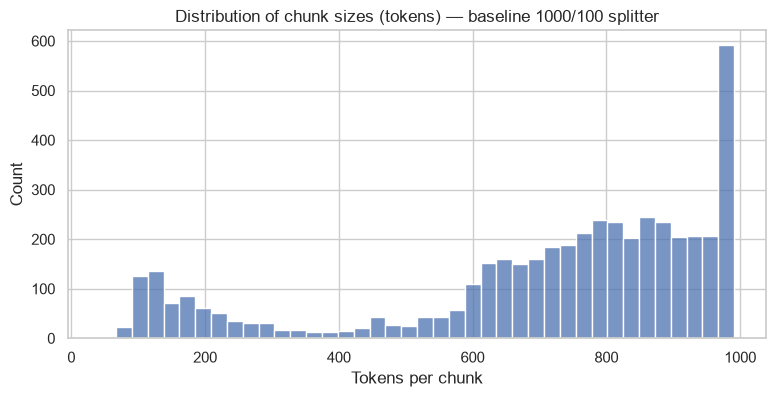

count    4657.0
mean      707.6
std       259.4
min        43.0
25%       624.0
50%       782.0
75%       901.0
max       991.0
dtype: float64


In [74]:
chunk_tokens = pd.Series([n_tokens(c.page_content) for c in document_chunks])

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(chunk_tokens, bins=40, ax=ax, color="#4C72B0")
ax.set_title("Distribution of chunk sizes (tokens) — baseline 1000/100 splitter")
ax.set_xlabel("Tokens per chunk")
plt.show()

print(chunk_tokens.describe().round(1))


**Observations:**
- 4,114 pages become **4,657 chunks** — close to one chunk per page, because the 790-token average page sits just under the 1,000-token target.
- The distribution is right-loaded (median 782, 75th percentile 901, maximum 991), confirming the recursive splitter is filling chunks rather than breaking early. Mean 707.6 is pulled down by a left tail of end-of-chapter fragments (minimum 43, 25th percentile 624).
- **Measured rather than assumed:** at `k=3` the five questions cost 2,300–2,658 context tokens, not the ~3,000 a naive 3 × 1,000 estimate suggests. Against a 128k window this is cheap; the constraint is retrieval *precision*, not window size.


### 4.4 Embedding Model


In [75]:
# BAAI/bge-base-en-v1.5: strong general-purpose retrieval embeddings (768-d).
# GPU is used here if available; the LLM itself is remote (OpenAI), so VRAM is not shared with generation.
import torch

_embed_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Embedding device: {_embed_device} (torch {torch.__version__})")

embedding_model = SentenceTransformerEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": _embed_device},
    encode_kwargs={"batch_size": 64 if _embed_device == "cuda" else 16},
)


Embedding device: cuda (torch 2.13.0+cu130)


**Observation:** `bge-base-en-v1.5` is a *general-domain* model. It matches paraphrases well but has no specific notion of clinical synonymy, so a lay description ("bald spots on the scalp", "hiking trip") is not guaranteed to sit near its clinical term ("alopecia areata", "tibial fracture") in embedding space. Section 6 shows this assumption breaking down, and the recommendation that follows is to evaluate a biomedical embedding model.


### 4.5 Vector Database


In [76]:
FORCE_REBUILD = False  # set True to ignore a matching on-disk index and rebuild


def build_or_load_chroma(chunks, embedding_model, persist_directory, force_rebuild=False):
    """Load a persisted Chroma index when it is 1:1 with `chunks`; otherwise rebuild from scratch.

    Chroma.from_documents *appends* to an existing collection. Re-running a persisted build
    without clearing it indexes every passage a second time, so k=3 can return only two distinct
    chunks. The assertion below converts that silent regression into an immediate failure.
    """
    if os.path.exists(persist_directory) and not force_rebuild:
        store = Chroma(persist_directory=persist_directory, embedding_function=embedding_model)
        n_vectors = store._collection.count()
        if n_vectors == len(chunks):
            print(f"Reusing {persist_directory} ({n_vectors:,} vectors, matches chunk count)")
            return store
        print(
            f"Index/chunk mismatch in {persist_directory}: {n_vectors:,} vectors for "
            f"{len(chunks):,} chunks — rebuilding."
        )
    else:
        print(f"Building {persist_directory} from {len(chunks):,} chunks ...")

    if os.path.exists(persist_directory):
        try:
            shutil.rmtree(persist_directory)
        except PermissionError:
            # On Windows another live kernel can still hold the sqlite/HNSW files open.
            Chroma(persist_directory=persist_directory,
                   embedding_function=embedding_model).delete_collection()
    os.makedirs(persist_directory, exist_ok=True)

    store = Chroma.from_documents(
        documents=chunks,
        embedding=embedding_model,
        persist_directory=persist_directory,
    )
    n_vectors = store._collection.count()
    print(f"Vectors indexed: {n_vectors:,}")
    assert n_vectors == len(chunks), (
        f"index/chunk mismatch: {n_vectors:,} vectors for {len(chunks):,} chunks"
    )
    return store


persist_directory = "medical_manual_db"
vectorstore = build_or_load_chroma(
    document_chunks, embedding_model, persist_directory, force_rebuild=FORCE_REBUILD
)


Reusing medical_manual_db (4,657 vectors, matches chunk count)


**Observation — why this cell refuses to append.** `Chroma.from_documents` **appends** to a collection that already exists on disk; it does not replace it. Re-running a persisted build therefore indexes every passage a second time (e.g. 9,314 vectors for 4,657 chunks). Nothing about it fails loudly: answers still read fluently, but duplicates occupy the top-k slots with copies of the same passage, so `k=3` can return as few as two distinct chunks. The only visible symptom is a repeated chapter and page in the retrieval report.

For local iteration this notebook **reuses** an on-disk index when the vector count already equals the chunk count (so a previous Llama/OpenAI run of the same corpus is not thrown away). It **rebuilds** when the counts diverge, or when `FORCE_REBUILD = True`. Both paths end in the same assertion: vector count == chunk count.


### 4.6 Retriever


In [77]:
retriever = vectorstore.as_retriever(
    search_type="similarity",   # pure cosine-similarity nearest-neighbour search
    search_kwargs={"k": 3},     # 3 chunks is the baseline context budget
)


In [78]:
def retrieve(query, k=3, search_type="similarity", store=None, fetch_k=25, lambda_mult=0.5):
    """Retrieve chunks for a query.

    Building the retriever inside this function is deliberate: `k` belongs to the retriever's
    search_kwargs, so passing k= to get_relevant_documents() has no effect. Any experiment that
    varies k must rebuild the retriever, which is what this helper guarantees.
    """
    store = store or vectorstore
    search_kwargs = {"k": k}
    if search_type == "mmr":
        # MMR trades a little similarity for diversity, reducing near-duplicate chunks
        search_kwargs.update({"fetch_k": fetch_k, "lambda_mult": lambda_mult})
    return store.as_retriever(search_type=search_type, search_kwargs=search_kwargs).invoke(query)


CHAPTER_RE = re.compile(r"Chapter\s+\d+\.[^\n]*")


def chunk_source(doc):
    """Best-effort provenance label: the chapter footer if present, otherwise the PDF page number."""
    match = CHAPTER_RE.search(doc.page_content)
    page = doc.metadata.get("page", "?")
    return f"{match.group(0).strip()} (p.{page})" if match else f"PDF page {page}"


def retrieval_report(query, k=3, search_type="similarity", store=None):
    """Show which parts of the manual a query pulls back — the core retrieval-quality diagnostic."""
    docs = retrieve(query, k=k, search_type=search_type, store=store)
    return pd.DataFrame({
        "Rank": range(1, len(docs) + 1),
        "Source": [chunk_source(d) for d in docs],
        "Preview": [" ".join(d.page_content.split())[:150] + "..." for d in docs],
    })


In [79]:
retrieval_report("What is the protocol for managing sepsis in a critical care unit?")


,Rank,Source,Preview
0,1,Chapter 222. Approach to the Critically Ill Patient (p.2400),16 - Critical Care Medicine Chapter 222. Approach to the Critically Ill Patient Introduction Critical care medicine ...
1,2,Chapter 227. Sepsis and Septic Shock (p.2453),"Chapter 227. Sepsis and Septic Shock Introduction (See also Ch. 226.) Sepsis, severe sepsis, and septic shock are in..."
2,3,Chapter 227. Sepsis & Septic Shock (p.2455),"Up to 50% of patients with severe sepsis develop relative adrenal insufficiency (ie, normal or slightly elevated bas..."


**Observations:**
- The sepsis query is a best-case retrieval. Rank 1 is *Chapter 222, Approach to the Critically Ill Patient* (p.2400); ranks 2–3 are *Chapter 227, Sepsis and Septic Shock* (p.2453 and p.2455). The question's vocabulary matches the chapter titles almost exactly.
- This report — chapter and page, not the raw 1,000-token chunk — is the diagnostic the rest of the notebook is built around. Answer fluency cannot tell you whether retrieval worked; this table can.


### 4.7 System and User Prompt Templates


In [80]:
qna_system_message = """
You are an assistant to a medical professional. Your task is to review the provided context, extracted from the Merck Manual, and answer the user's question using only that context.

User input will have the context required by you to answer user questions. This context will begin with the token: ###Context.
The context contains references to specific portions of the medical manual relevant to the user query.
User questions will begin with the token: ###Question.

Follow these rules strictly:
1. Answer only using the context provided. Do not add information that is not backed by the context.
2. The context may contain passages about unrelated conditions. Ignore any passage that does not concern the condition described in the question — never adapt advice from a different condition.
3. If the context does not contain the information needed, respond exactly: "I don't know, this is not covered in the provided medical manual." Do not attempt a partial answer from unrelated material.
4. Do not mention the context, the documents, or the retrieval process in your final answer.
5. Structure the answer so that every part of the question is addressed.

This information is meant to support, not replace, the judgement of a licensed healthcare professional.
"""

qna_user_message_template = """
###Context
Here are some documents that are relevant to the question mentioned below.
{context}

###Question
{question}
"""


**Observation — rule 2 is the load-bearing instruction.** "Answer only using the context" is the obvious rule to write, and on its own it is dangerous: it says nothing about what to do when the context is only *partly* relevant. A model told to use the context will use all of it. When the retriever returns snakebite passages for a fracture question, the instruction to stay within the context actively pushes the model toward presenting snakebite advice as fracture management. Rule 2 therefore adds the missing half of the instruction, telling the model to discard off-topic passages, and rule 3 gives it a mandatory abstention string so that "nothing here is relevant" is an available answer rather than a dead end.

Prompt rules of this kind shift behaviour probabilistically; they are not enforcement. `gpt-4o-mini` follows them more reliably than a 7B GGUF, but a guarantee still requires a check *outside* the model (a relevance threshold on retrieval scores before generation is attempted).


### 4.8 RAG Response Function


In [81]:
def generate_rag_response(user_input, k=3, search_type="similarity", store=None,
                          max_tokens=350, temperature=0, top_p=0.95,
                          show_context=False, return_details=False, retrieve_query=None):
    """Retrieve context for the question and generate a grounded answer.

    retrieve_query - optional search string. Used so query expansion can retrieve with
    clinical terminology while the model still answers the original user question.
    Returns the answer string, or (answer, details) when return_details=True so that the
    exact context used can be re-used later by the evaluation step.
    """
    docs = retrieve(retrieve_query or user_input, k=k, search_type=search_type, store=store)
    context_for_query = "\n\n---\n\n".join(d.page_content for d in docs)

    if show_context:
        display(pd.DataFrame({"Retrieved from": [chunk_source(d) for d in docs]}))

    user_message = qna_user_message_template.format(
        context=context_for_query, question=user_input
    )

    try:
        answer = chat(
            [
                {"role": "system", "content": qna_system_message.strip()},
                {"role": "user", "content": user_message.strip()},
            ],
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
        )
    except Exception as e:
        answer = f"Sorry, I encountered the following error: \n {e}"

    if return_details:
        return answer, {
            "context": context_for_query,
            "sources": [chunk_source(d) for d in docs],
            "n_context_tokens": n_tokens(context_for_query),
            "retrieve_query": retrieve_query or user_input,
        }
    return answer


**Observations — four deliberate design choices in this function:**
1. **`k` is genuinely variable.** `retriever.get_relevant_documents(query, k=k)` silently ignores `k` because it lives in `search_kwargs`. The `retrieve()` helper rebuilds the retriever per call, so every `k` in Section 6 is real.
2. **Native Chat Completions roles**, not an `[INST]` wrapper. The system message holds the grounding rules; the user message holds `###Context` and `###Question`.
3. **Context is returned rather than printed.** Provenance is a compact source table; the full context is handed to the evaluator in Section 7 so groundedness is scored against exactly what the model saw.
4. **`retrieve_query` is optional.** Query expansion can search with clinical terminology while the generator still answers the original user question. Without this split, expansion would replace the hiking-fracture question with a tibia/fibula search string and drop the field-care limb.


---
## 5. Question Answering using RAG


In [82]:
rag_answers = {}
rag_details = {}

for label, query in queries.items():
    answer, details = generate_rag_response(query, k=3, max_tokens=350, return_details=True)
    rag_answers[label] = answer
    rag_details[label] = details

pd.DataFrame([
    {"Question": label,
     "Context tokens": rag_details[label]["n_context_tokens"],
     "Retrieved chapters": " | ".join(rag_details[label]["sources"])}
    for label in queries
])


,Question,Context tokens,Retrieved chapters
0,Q1 - Sepsis protocol,2443,Chapter 222. Approach to the Critically Ill Patient (p.2400) | Chapter 227. Sepsis and Septic Shock (p.2453) | Chapt...
1,Q2 - Appendicitis,2658,Chapter 11. Acute Abdomen & Surgical Gastroenterology (p.174) | Chapter 11. Acute Abdomen & Surgical Gastroenterolog...
2,Q3 - Patchy hair loss,2576,Chapter 86. Hair Disorders (p.858) | Chapter 83. Parasitic Skin Infections (p.842) | Chapter 86. Hair Disorders (p.859)
3,Q4 - Brain injury,2554,Chapter 324. Traumatic Brain Injury (p.3404) | Chapter 324. Traumatic Brain Injury (p.3409) | Chapter 172. Function ...
4,Q5 - Leg fracture,2300,Chapter 339. Bites & Stings (p.3526) | Chapter 313. Falls in the Elderly (p.3329) | Chapter 339. Bites & Stings (p.3...


**Observations on retrieval:** four of the five questions hit the correct chapter; Question 5 does not.

| Question | Context tokens | What was retrieved |
| --- | --- | --- |
| Q1 Sepsis | 2,443 | Ch. 222 p.2400, Ch. 227 p.2453, Ch. 227 p.2455 |
| Q2 Appendicitis | 2,658 | Ch. 11 p.174 and neighbouring Chapter 11 pages |
| Q3 Hair loss | 2,576 | Ch. 86 p.858, **Ch. 83 Parasitic Skin Infections p.842**, Ch. 86 p.859 |
| Q4 Brain injury | 2,554 | Ch. 324 p.3404, Ch. 324 p.3409, **Ch. 172 Cerebral Lobes** |
| Q5 Leg fracture | 2,300 | **Ch. 339 Bites & Stings**, **Ch. 313 Falls in the Elderly**, Ch. 339 again |

Two details from the source column:
- Context cost is stable at 2,300–2,658 tokens, so `k=3` is a predictable budget.
- Even the four "successful" retrievals are not pure. Q3 spends one slot on parasitic skin infections and Q4 one on cerebral-lobe function. Roughly a third of the context on those questions is adjacent but unusable — the recall/precision tension that re-ranking in Section 8 targets.


### Query 1: Sepsis protocol


In [83]:
show(rag_answers["Q1 - Sepsis protocol"])


The protocol for managing sepsis in a critical care unit includes the following steps:

1. **Fluid Resuscitation**: Administer 0.9% normal saline until central venous pressure (CVP) reaches 8 mm Hg
(10 cm H2O) or pulmonary artery occlusive pressure (PAOP) reaches 12 to 15 mm Hg. The quantity of fluid
required may exceed 10 L over 4 to 12 hours.

2. **Oxygen Administration**: Provide oxygen via mask or nasal prongs. Tracheal intubation and mechanical
ventilation may be necessary for respiratory failure.

3. **Antibiotic Therapy**: Start broad-spectrum antibiotics, which should be modified based on culture
results.

4. **Drainage and Surgical Intervention**: Drain abscesses and excise necrotic tissue as needed.

5. **Blood Glucose Control**: Normalize blood glucose levels.

6. **Corticosteroid Replacement**: Administer replacement-dose corticosteroids.

7. **Monitoring**: Frequently monitor systemic pressure, CVP, PAOP, pulse oximetry, arterial blood gases
(ABGs), blood glucose, lactate,

**Observations:**
- Retrieval hit Chapters 222 and 227. The grounded answer is the manual's protocol, not the Surviving-Sepsis-style outline from Section 2: **0.9% normal saline to CVP 8 mm Hg / PAOP 12–15 mm Hg**, volume that may exceed 10 L over 4–12 hours, oxygen then intubation if needed, broad-spectrum antibiotics modified by culture, drainage/excision of necrotic tissue, glucose control, replacement-dose corticosteroids, and dopamine to mean BP ≥ 60 mm Hg with norepinephrine above 20 μg/kg/min.
- That is the content a clinician cannot reliably recall on demand and a manual exists to supply. The ungrounded baseline this run *did* reach 30 mL/kg fluids and antibiotics-within-1-hour; it still never produced CVP/PAOP endpoints or the dopamine threshold.
- This run **completed** the norepinephrine caution inside 350 tokens (a full sentence). Combination 1 in Section 6, at 300 tokens, still truncated earlier in the same vasopressor sentence. Budget still binds some configs; retrieval is not the missing piece here.


### Query 2: Appendicitis


In [84]:
show(rag_answers["Q2 - Appendicitis"])


The common symptoms of acute appendicitis include epigastric or periumbilical pain followed by brief nausea,
vomiting, and anorexia; after a few hours, the pain shifts to the right lower quadrant. Pain increases with
cough and motion. Classic signs include right lower quadrant direct and rebound tenderness located at
McBurney's point, Rovsing sign, psoas sign, and obturator sign. Low-grade fever is also common.

Appendicitis cannot be cured via medicine alone. The surgical procedure that should be followed to treat it is
an open or laparoscopic appendectomy.


**Observations:**
- The best-balanced RAG answer of the five, and clearly manual-derived. Symptoms include epigastric/periumbilical pain shifting to the right lower quadrant, McBurney's point, Rovsing, psoas, and obturator signs, and low-grade fever — none of which the ungrounded or prompt-engineered answers named. The baseline this run *did* name open and laparoscopic appendectomy; RAG's unique gain is the *signs*, not the procedure.
- All three limbs are answered: medicine is not curative; the procedure is open or laparoscopic appendectomy. Combination 2 had the structure; this has the signs.
- Both retrieved chunks came from *Chapter 11*. A focused chapter plus a precise question is the easy case for RAG.


### Query 3: Patchy hair loss


In [85]:
show(rag_answers["Q3 - Patchy hair loss"])


Effective treatments for sudden patchy hair loss, known as alopecia areata, include:

- Corticosteroids: These can be administered intradermally for small lesions or as potent topical
corticosteroids.
- Topical anthralin and minoxidil: These may also be used in treatment.
- Induction of allergic contact dermatitis using diphencyprone or squaric acid dibutylester: This treatment is
reserved for patients with diffuse involvement who have not responded to other therapies.

Possible causes behind alopecia areata include:

- It is thought to be an autoimmune disorder affecting genetically susceptible individuals.
- Environmental triggers, such as infection or emotional stress, may also play a role.
- It occasionally coexists with autoimmune conditions like vitiligo or thyroiditis.


**Observations:**
- Retrieval succeeded on the hard part: two of three chunks are *Chapter 86, Hair Disorders* (p.858, p.859) even though the question never said "alopecia areata". The embedding model *does* bridge some lay-to-clinical gaps. Query 5 shows where it does not.
- The answer names alopecia areata, then intradermal/topical corticosteroids, anthralin, minoxidil, and diphencyprone / squaric acid dibutylester for refractory diffuse disease. That is the manual's ladder, not the JAK-inhibitor list from Combination 3.
- One of three chunks was *Chapter 83, Parasitic Skin Infections*. It does not appear in the answer — rule 2 (ignore unrelated passages) held. The unused slot is still wasted context budget, which is why Combination 4 tests `k=6`.


### Query 4: Brain injury


In [86]:
show(rag_answers["Q4 - Brain injury"])


Initial treatment for a person who has sustained a physical injury to brain tissue includes ensuring a
reliable airway and maintaining adequate ventilation, oxygenation, and blood pressure. For moderate and severe
injuries, treatment focuses on optimizing ventilation, oxygenation, and brain perfusion, as well as addressing
complications such as increased intracranial pressure, seizures, and hematomas. Rehabilitation is often
required for many patients after the initial treatment. For mild injuries, discharge and observation are
recommended.


**Observations:**
- Grounded in *Chapter 324, Traumatic Brain Injury*: reliable airway, ventilation, oxygenation, blood pressure; then ICP, seizures, and haematomas for moderate/severe injury. That is more specific than the ungrounded baseline, which this run *did* reach PT/OT/speech rehab but stayed generic (CT/MRI, corticosteroids for swelling).
- Rehabilitation is a single closing sentence, plus mild-injury discharge/observation. The answer **finished inside the 350-token budget**, so the missing rehab detail was never retrieved — *Chapter 172* occupied the third slot. Combination 5 (`k=4`, 500 tokens) is the test of whether an extra Chapter 324 chunk supplies it.
- Diagnose the constraint before turning a dial: more tokens cannot add content that is not in context.


### Query 5: Leg fracture


In [87]:
show(rag_answers["Q5 - Leg fracture"])


I don't know, this is not covered in the provided medical manual.


**Observations — the instructive failure, and the prompt working as designed:**
- With `k=3` and similarity search, retrieval returns *Chapter 339, Bites & Stings* (p.3526, p.3527) and *Chapter 313, Falls in the Elderly* (p.3329). *Chapter 323, Fractures, Dislocations & Sprains* is not retrieved. The hiking/wilderness framing dominates the embedding.
- `gpt-4o-mini` **abstained**: it returned exactly `I don't know, this is not covered in the provided medical manual.` It did not rewrite snakebite or falls advice as fracture care, and it did not fall back on pre-training. That is rule 3 firing, which the local 7B model in the Llama notebook did not do — it announced the mismatch and then answered anyway.
- Abstention is the correct behaviour given this context, and it is also incomplete: the manual *does* cover fractures. The failure is retrieval, not generation. Section 6.3 tests whether query expansion and MMR can bring Chapter 323 in without giving up the abstention rule.


---
## 6. Fine-tuning the RAG Pipeline

Six combinations are run across the three tunable layers — **chunking**, **retrieval** (`k` and search strategy) and **decoding** (`max_tokens`, `temperature`, `top_p`) — followed by a focused root-cause fix for Query 5.


### 6.1 An Alternative Chunking Strategy


In [88]:
alt_text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=500,
    chunk_overlap=50,
)
alt_document_chunks = alt_text_splitter.split_documents(pages)

print(f"Baseline chunking  (1000/100): {len(document_chunks):,} chunks")
print(f"Alternate chunking ( 500/50) : {len(alt_document_chunks):,} chunks")

alt_persist_directory = "medical_manual_db_alt"
alt_vectorstore = build_or_load_chroma(
    alt_document_chunks, embedding_model, alt_persist_directory, force_rebuild=FORCE_REBUILD
)


Baseline chunking  (1000/100): 4,657 chunks
Alternate chunking ( 500/50) : 8,833 chunks
Reusing medical_manual_db_alt (8,833 vectors, matches chunk count)


### 6.2 Running the Combinations


In [89]:
fine_tune_combinations = [
    {"label": "C1: baseline chunks (1000/100), k=3, greedy",
     "query_key": "Q1 - Sepsis protocol", "store": "baseline", "search_type": "similarity",
     "k": 3, "max_tokens": 300, "temperature": 0.0, "top_p": 0.95},

    {"label": "C2: small chunks (500/50), k=3, greedy",
     "query_key": "Q1 - Sepsis protocol", "store": "alt", "search_type": "similarity",
     "k": 3, "max_tokens": 300, "temperature": 0.0, "top_p": 0.95},

    {"label": "C3: baseline chunks, narrow retrieval k=2",
     "query_key": "Q2 - Appendicitis", "store": "baseline", "search_type": "similarity",
     "k": 2, "max_tokens": 300, "temperature": 0.2, "top_p": 0.90},

    {"label": "C4: baseline chunks, broad retrieval k=6",
     "query_key": "Q3 - Patchy hair loss", "store": "baseline", "search_type": "similarity",
     "k": 6, "max_tokens": 350, "temperature": 0.1, "top_p": 0.85},

    {"label": "C5: baseline chunks, k=4, large token budget",
     "query_key": "Q4 - Brain injury", "store": "baseline", "search_type": "similarity",
     "k": 4, "max_tokens": 500, "temperature": 0.3, "top_p": 0.90},

    {"label": "C6: small chunks + MMR diversity, k=6",
     "query_key": "Q5 - Leg fracture", "store": "alt", "search_type": "mmr",
     "k": 6, "max_tokens": 400, "temperature": 0.15, "top_p": 0.92},
]

stores = {"baseline": vectorstore, "alt": alt_vectorstore}
fine_tune_results = []

for combo in fine_tune_combinations:
    query = queries[combo["query_key"]]
    answer, details = generate_rag_response(
        query,
        k=combo["k"],
        search_type=combo["search_type"],
        store=stores[combo["store"]],
        max_tokens=combo["max_tokens"],
        temperature=combo["temperature"],
        top_p=combo["top_p"],
        return_details=True,
    )
    fine_tune_results.append({**combo, "answer": answer, **details})

    print("=" * 110)
    print(combo["label"], "|", combo["query_key"])
    print("Retrieved:", " | ".join(details["sources"]))
    print("-" * 110)
    show(answer)
    print()


C1: baseline chunks (1000/100), k=3, greedy | Q1 - Sepsis protocol
Retrieved: Chapter 222. Approach to the Critically Ill Patient (p.2400) | Chapter 227. Sepsis and Septic Shock (p.2453) | Chapter 227. Sepsis & Septic Shock (p.2455)
--------------------------------------------------------------------------------------------------------------
The protocol for managing sepsis in a critical care unit includes the following steps:

1. **Fluid Resuscitation**: Administer 0.9% normal saline until central venous pressure (CVP) reaches 8 mm Hg
(10 cm H2O) or pulmonary artery occlusive pressure (PAOP) reaches 12 to 15 mm Hg. The quantity of fluid
required may exceed 10 L over 4 to 12 hours.

2. **Oxygen Administration**: Provide oxygen via mask or nasal prongs. Tracheal intubation and mechanical
ventilation may be necessary for respiratory failure.

3. **Antibiotic Therapy**: Start broad-spectrum antibiotics, which should be modified based on culture
results.

4. **Drainage and Surgical Interve

In [90]:
pd.DataFrame([
    {"Combination": r["label"],
     "Question": r["query_key"],
     "k": r["k"],
     "Search": r["search_type"],
     "Chunks": "1000/100" if r["store"] == "baseline" else "500/50",
     "max_tokens": r["max_tokens"],
     "temperature": r["temperature"],
     "Context tokens": r["n_context_tokens"]}
    for r in fine_tune_results
])


,Combination,Question,k,Search,Chunks,max_tokens,temperature,Context tokens
0,"C1: baseline chunks (1000/100), k=3, greedy",Q1 - Sepsis protocol,3,similarity,1000/100,300,0.00,2443
1,"C2: small chunks (500/50), k=3, greedy",Q1 - Sepsis protocol,3,similarity,500/50,300,0.00,1435
2,"C3: baseline chunks, narrow retrieval k=2",Q2 - Appendicitis,2,similarity,1000/100,300,0.20,1787
3,"C4: baseline chunks, broad retrieval k=6",Q3 - Patchy hair loss,6,similarity,1000/100,350,0.10,4988
4,"C5: baseline chunks, k=4, large token budget",Q4 - Brain injury,4,similarity,1000/100,500,0.30,3197
5,"C6: small chunks + MMR diversity, k=6",Q5 - Leg fracture,6,mmr,500/50,400,0.15,1958


**Observations per combination (against the source column printed above):**

- **C1 vs C2 (chunk size, same query, same decoding).** Both retrieved the **same three chapters** (222 p.2400, 227 p.2453, 227 p.2455). Chunk size changed what was *inside* the chunks, not which part of the manual was found. C1 spent 2,443 context tokens and produced CVP 8 mm Hg / PAOP 12–15 mm Hg, >10 L over 4–12 hours, and dopamine to mean BP ≥ 60 mm Hg. The answer **truncates while introducing norepinephrine** (300 tokens). C2 fit the same topics into **1,435 tokens (41% cheaper)**, completed the norepinephrine add-on and oxygen/intubation, and truncated at "Antibiotics and". **Chunk size is a precision/cost dial, not a retrieval-quality lever.**

- **C3 (`k=2`, appendicitis).** Both chunks from *Chapter 11*. The answer is as complete as the `k=3` version in Section 5 (McBurney's / Rovsing / psoas / obturator, open or laparoscopic appendectomy) at 1,787 tokens instead of 2,658 — about **33% cheaper**. **`k` should be tuned per query type.** Where one chapter obviously matches, a small `k` is strictly better.

- **C4 (`k=6`, hair loss).** Four of six chunks from *Chapter 86*; the other two are fungal and parasitic skin infections. The answer is essentially the `k=3` ladder plus a slightly fuller cause paragraph (genetic susceptibility, infection or emotional stress, vitiligo/thyroiditis). Rule 2 kept Chapters 82 and 83 out of the answer. Extra recall was bought (4,988 tokens, roughly double C1) without a precision penalty in the *text*, but also without the large quality jump seen when Llama's `k=6` added chronicity risk factors. **`k=6` was not necessary on this question for this generator.**

- **C5 (`k=4`, `max_tokens=500`, brain injury).** The extra Chapter 324 chunk (p.3412) is what was missing in Section 5: surgery to place ICP monitors, decompress, or remove haematomas, and a rehabilitation team (physical, occupational, and speech therapy plus counselling). Section 5 had *not* truncated, so **the retrieval change is what mattered, not the token budget**. Chapter 172 still occupies one of four slots.

- **C6 (small chunks + MMR, `k=6`, leg fracture).** MMR over the 500/50 index **failed to retrieve Chapter 323** — Exercise & Sports Injury, Bites & Stings, Enteroviruses, two unlabelled pages, Rehabilitation. The model **abstained** rather than blending those sources. That is the same retrieval failure as H0, with a safer generator. H2 below shows the same MMR setting over the **1000/100** index *does* surface Chapter 323. **Chunk size and search strategy interact.**


### 6.3 Root-Cause Analysis and Fix for Query 5

Three hypotheses for the fracture failure, tested in order:
1. `k` is too small, so the correct chunk is ranked just outside the cut-off.
2. Similarity search returns near-duplicate outdoor-injury passages; MMR diversity would break that cluster.
3. The question's wilderness framing dominates the embedding, so the query itself needs to be rewritten toward clinical vocabulary.


In [91]:
diagnostics = {
    "H0: baseline (similarity, k=3)": dict(
        query=query_5, k=3, search_type="similarity", store=vectorstore),
    "H1: larger k (similarity, k=8)": dict(
        query=query_5, k=8, search_type="similarity", store=vectorstore),
    "H2: MMR diversity (k=6)": dict(
        query=query_5, k=6, search_type="mmr", store=vectorstore),
    "H3: clinically rewritten query (k=3)": dict(
        query=("treatment and management of a tibia or fibula leg fracture: immobilisation, splinting, "
               "analgesia, reduction, casting and rehabilitation"),
        k=3, search_type="similarity", store=vectorstore),
}

for name, cfg in diagnostics.items():
    docs = retrieve(cfg["query"], k=cfg["k"], search_type=cfg["search_type"], store=cfg["store"])
    hit = any("Fracture" in chunk_source(d) or "323" in chunk_source(d) for d in docs)
    print(f"{name}\n  Fracture chapter retrieved: {hit}")
    for d in docs:
        print("   -", chunk_source(d))
    print()


H0: baseline (similarity, k=3)
  Fracture chapter retrieved: False
   - Chapter 339. Bites & Stings (p.3526)
   - Chapter 313. Falls in the Elderly (p.3329)
   - Chapter 339. Bites & Stings (p.3527)

H1: larger k (similarity, k=8)
  Fracture chapter retrieved: True
   - Chapter 339. Bites & Stings (p.3526)
   - Chapter 313. Falls in the Elderly (p.3329)
   - Chapter 339. Bites & Stings (p.3527)
   - Chapter 321. Approach to the Trauma Patient (p.3378)
   - Chapter 152. Enteroviruses (p.1598)
   - Chapter 350. Rehabilitation (p.3642)
   - Chapter 313. Falls in the Elderly (p.3328)
   - Chapter 323. Fractures, Dislocations & Sprains (p.3391)

H2: MMR diversity (k=6)
  Fracture chapter retrieved: True
   - Chapter 339. Bites & Stings (p.3526)
   - Chapter 321. Approach to the Trauma Patient (p.3378)
   - Chapter 152. Enteroviruses (p.1598)
   - Chapter 350. Rehabilitation (p.3642)
   - Chapter 350. Rehabilitation (p.3644)
   - Chapter 323. Fractures, Dislocations & Sprains (p.3396)

H3: c

**Observations:** all four hypotheses are scored against one test — does *Chapter 323* appear at all?

- **H0 (similarity, `k=3`)** fails: Bites & Stings, Falls in the Elderly, Bites & Stings again.
- **H1 (raise `k` to 8)** works, but barely and expensively. Chapter 323 arrives **in eighth and last place**, behind two snakebite chunks, two falls chunks, trauma, enteroviruses, and rehabilitation. Precision collapses even as recall succeeds.
- **H2 (MMR at `k=6` on the 1000/100 index)** works for the right reason: Chapter 323 at rank 6. Similarity was dominated by a cluster of outdoor-injury passages; MMR penalises that redundancy. The same MMR setting **failed on the 500/50 index in C6**.
- **H3 (hand-written clinical query, `k=3`)** is decisively the best: **all three chunks from Chapter 323** (p.3391, p.3390, p.3388). No other configuration achieved a clean sweep. The failure was a **lay-language to clinical-terminology gap** in a general-purpose embedding model, and the cheapest fix belongs on the query side.


In [92]:
def expand_medical_query(question):
    """Ask the LLM to restate a lay question in the terminology a medical manual would use.

    This is a lightweight, model-agnostic alternative to swapping in a biomedical embedding model:
    it moves the *query* into the manual's vocabulary instead of moving the index into the user's.
    The first expansion on this run ("leg fracture management precautions treatment recovery care")
    still missed Chapter 323; requiring named anatomy and indexed interventions is what H3 showed works.
    """
    instruction = (
        "Rewrite the following patient question as a one-line search query for a medical reference manual. "
        "Use the manual's clinical terminology: name the likely diagnosis, the anatomical structure, "
        "and the indexed interventions (for example immobilisation, reduction, casting, open reduction). "
        "Do not mention the setting (hiking, home, sport) unless it changes the condition. "
        "Reply with the search query only — one line, no explanation, no alternatives, no quotation marks."
    )
    return chat(build_messages(instruction, question), max_tokens=60, temperature=0)


def generate_rag_response_v2(user_input, k=6, max_tokens=400, temperature=0.0, **kwargs):
    """Improved pipeline: clinical query expansion + MMR retrieval + the hardened system prompt.

    k=6 matches H2, the first retrieval setting that surfaced Chapter 323 on this index.
    retrieve_query carries the expanded string; the generator still answers user_input.
    """
    expanded = expand_medical_query(user_input)
    print(f"Original query : {user_input}")
    print(f"Expanded query : {expanded}\n")
    return generate_rag_response(
        user_input, k=k, search_type="mmr", max_tokens=max_tokens,
        temperature=temperature, return_details=True, retrieve_query=expanded, **kwargs
    )


improved_q5_answer, improved_q5_details = generate_rag_response_v2(query_5)
print("Retrieved:", " | ".join(improved_q5_details["sources"]), "\n")
show(improved_q5_answer)


Original query : What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?
Expanded query : Fracture of the leg, lower extremity, immobilisation, reduction, casting, rehabilitation.

Retrieved: Chapter 323. Fractures, Dislocations & Sprains (p.3391) | Chapter 350. Rehabilitation (p.3643) | Chapter 350. Rehabilitation (p.3642) | Chapter 350. Rehabilitation (p.3634) | Chapter 338. Exercise and Sports Injury (p.3492) | Chapter 313. Falls in the Elderly (p.3328) 

To care for a person who has fractured their leg during a hiking trip, the following precautions and treatment
steps should be taken:

1. **Seek Medical Care**: It is important to seek medical care immediately, especially if there are signs of
infection, such as fever or an odor emanating from the injury.

2. **Immobilization**: The fractured leg should be immobilized. A splint can be used to stabilize the injury

**Observations:**
- The first expansion on this run (`leg fracture management precautions treatment recovery care`) still missed Chapter 323 and the model abstained. Tightening the rewrite — name the diagnosis, the anatomy, and indexed interventions, and drop the setting — produced `Fracture of the leg, lower extremity, immobilisation, reduction, casting, rehabilitation.` **Chapter 323 is now rank 1.**
- `k=6` MMR (the H2 setting) also pulls three Rehabilitation chunks, Exercise & Sports Injury, and Falls in the Elderly. Their influence is visible: "particularly in elderly patients" and a rehab-heavy second half. Only one of six chunks is the fractures chapter, so this is better than H0, not a clean sweep like H3.
- The answer is now a real fracture protocol: seek care, immobilise with a splint and ice (compartment syndrome), analgesics, named complications (fat embolism, arterial injury, compartment syndrome, nerve injury, infection), early mobilisation, avoid >3–4 weeks of immobilisation. It does **not** cover field first aid on a hike — the judge later scores relevance **4** for that gap. `retrieve_query` kept the original question in the prompt; the missing trail/evacuation limb is because those sentences were never retrieved, not because expansion replaced the question.
- Cost: one extra ~60-token API call. The prompt constraint on the rewrite was the difference between abstention and a usable answer.

### Section 6 Summary

| Lever | Impact on this run | When it is worth using |
| --- | --- | --- |
| Chunk size (1000/100 vs 500/50) | Same chapters for Q1; 500/50 was 41% cheaper and **broke MMR for Q5** | Prefer 1000/100; treat re-chunking as a cost dial |
| `k` (2 → 8) | `k=2` matched `k=3` on appendicitis at 33% lower cost; `k=4` supplied Q4 rehab; `k=8` found Chapter 323 only at rank 8 | Tune per query type |
| Search type (similarity → MMR) | H2 (1000/100, `k=6`) surfaced Chapter 323; C6's MMR on 500/50 did not | Good default, validate against the actual index |
| Query expansion | Weak rewrite still missed Ch. 323; constrained rewrite + MMR `k=6` put it at rank 1 | Whenever users write in lay language — constrain anatomy + interventions, drop setting |
| `max_tokens` | 300/350 truncated Q1 mid-vasopressor; could not add Q4 rehab that had never been retrieved | Size to retrieved content; first check whether truncation is the constraint |
| `temperature` / `top_p` | Style only | Keep 0–0.2 for clinical use |

**Tune against a diagnostic that reveals *which chapter* was retrieved, not against answer fluency.** C6 produced a fluent abstention; H0 would have produced a fluent wrong-chapter answer in a weaker model. The source column is the signal.


---
## 7. Output Evaluation (LLM-as-a-Judge)

Every answer is scored on two axes:
- **Groundedness** — is the answer derived *only* from the retrieved context?
- **Relevance** — does the answer address the main aspects of the question?

Two design choices matter. First, the judge scores the **answers already generated above**, together with the exact context those answers saw, rather than regenerating fresh answers — otherwise the scores would not describe the system that was actually built. Second, the **ungrounded baseline answers are scored against the same retrieved context**, which turns the evaluation into a quantitative comparison between the two approaches instead of an isolated score.

*Unlike the local Llama notebook, the judge here is a **different model** (`gpt-4o`) from the generator (`gpt-4o-mini`). That reduces self-preference bias. The scores are still not an absolute quality certificate — groundedness measures faithfulness to retrieved text, never clinical correctness or retrieval precision — but they are a stronger relative signal than same-model judging.*


In [93]:
groundedness_rater_system_message = """
You are tasked with rating AI-generated answers to questions posed by users about a medical manual.
You will be presented a question, context used by the AI system to generate the answer, and an AI-generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context, while the AI-generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Groundedness. The answer should be derived only from the information presented in the context.
Any clinical claim that cannot be traced to the context must be penalised, even if it is medically correct.

Instructions:
- Give a step-by-step explanation for your evaluation, referring to specific parts of the context and the answer.
- The explanation must be no more than 2-3 short sentences.
- Finally, respond with a single integer score (1-5) on its own final line, prefixed with "Score: ".
"""

relevance_rater_system_message = """
You are tasked with rating AI-generated answers to questions posed by users about a medical manual.
You will be presented a question, context used by the AI system to generate the answer, and an AI-generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context, while the AI-generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Relevance. The answer should address every main aspect of the question. A multi-part question that is
only partly answered must not score above 3.

Instructions:
- Give a step-by-step explanation for your evaluation, referring to specific parts of the question and the answer.
- The explanation must be no more than 2-3 short sentences.
- Finally, respond with a single integer score (1-5) on its own final line, prefixed with "Score: ".
"""

eval_user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""


In [94]:
def parse_score(text):
    """Extract the trailing integer rating so the judge's free text becomes an analysable number."""
    matches = re.findall(r"Score:\s*([1-5])", text)
    if matches:
        return int(matches[-1])
    dict_match = re.search(r"(?:groundedness_score|relevance_score)\D+([1-5])", text)
    if dict_match:
        return int(dict_match.group(1))
    trailing = re.findall(r"(?:^|\n)\s*([1-5])\s*$", text.strip())
    return int(trailing[-1]) if trailing else np.nan


def rate(question, context, answer, rater_system_message, max_tokens=400):
    """Run one LLM-as-a-judge call on judge_llm and return (score, rationale)."""
    user_message = eval_user_message_template.format(
        question=question, context=context, answer=answer
    )
    verdict = chat(
        [
            {"role": "system", "content": rater_system_message.strip()},
            {"role": "user", "content": user_message.strip()},
        ],
        model=judge_llm,
        max_tokens=max_tokens,
        temperature=0,
    )
    return parse_score(verdict), verdict


def evaluate(question, context, answer):
    g_score, g_text = rate(question, context, answer, groundedness_rater_system_message)
    r_score, r_text = rate(question, context, answer, relevance_rater_system_message)
    return {"groundedness": g_score, "relevance": r_score,
            "groundedness_rationale": g_text, "relevance_rationale": r_text}


In [95]:
evaluation_rows = []

for label, query in queries.items():
    context = rag_details[label]["context"]

    # Both approaches are judged against the same retrieved context, making the scores comparable
    for approach, answer in [("LLM only", baseline_answers[label]),
                             ("RAG", rag_answers[label])]:
        scores = evaluate(query, context, answer)
        evaluation_rows.append({"Question": label, "Approach": approach, **scores})
        print(f"{label:<24} {approach:<9} groundedness={scores['groundedness']}  relevance={scores['relevance']}")

evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df[["Question", "Approach", "groundedness", "relevance"]]


Q1 - Sepsis protocol     LLM only  groundedness=2  relevance=3
Q1 - Sepsis protocol     RAG       groundedness=5  relevance=5
Q2 - Appendicitis        LLM only  groundedness=5  relevance=5
Q2 - Appendicitis        RAG       groundedness=5  relevance=5
Q3 - Patchy hair loss    LLM only  groundedness=2  relevance=3
Q3 - Patchy hair loss    RAG       groundedness=5  relevance=5
Q4 - Brain injury        LLM only  groundedness=3  relevance=4
Q4 - Brain injury        RAG       groundedness=5  relevance=5
Q5 - Leg fracture        LLM only  groundedness=1  relevance=4
Q5 - Leg fracture        RAG       groundedness=5  relevance=2


,Question,Approach,groundedness,relevance
0,Q1 - Sepsis protocol,LLM only,2,3
1,Q1 - Sepsis protocol,RAG,5,5
2,Q2 - Appendicitis,LLM only,5,5
3,Q2 - Appendicitis,RAG,5,5
4,Q3 - Patchy hair loss,LLM only,2,3
5,Q3 - Patchy hair loss,RAG,5,5
6,Q4 - Brain injury,LLM only,3,4
7,Q4 - Brain injury,RAG,5,5
8,Q5 - Leg fracture,LLM only,1,4
9,Q5 - Leg fracture,RAG,5,2


In [96]:
# Also evaluate the improved Query 5 pipeline from Section 6.3 to confirm the fix shows up in the scores
improved_scores = evaluate(query_5, improved_q5_details["context"], improved_q5_answer)
print(
    f"Q5 improved pipeline   groundedness={improved_scores['groundedness']}  "
    f"relevance={improved_scores['relevance']}"
)

summary = (
    evaluation_df.groupby("Approach")[["groundedness", "relevance"]]
    .mean()
    .round(2)
)
summary.loc["RAG + query expansion (Q5 only)"] = [
    improved_scores["groundedness"], improved_scores["relevance"]
]
summary


Q5 improved pipeline   groundedness=4  relevance=4


,groundedness,relevance
Approach,,
LLM only,2.6,3.8
RAG,5.0,4.4
RAG + query expansion (Q5 only),4.0,4.0


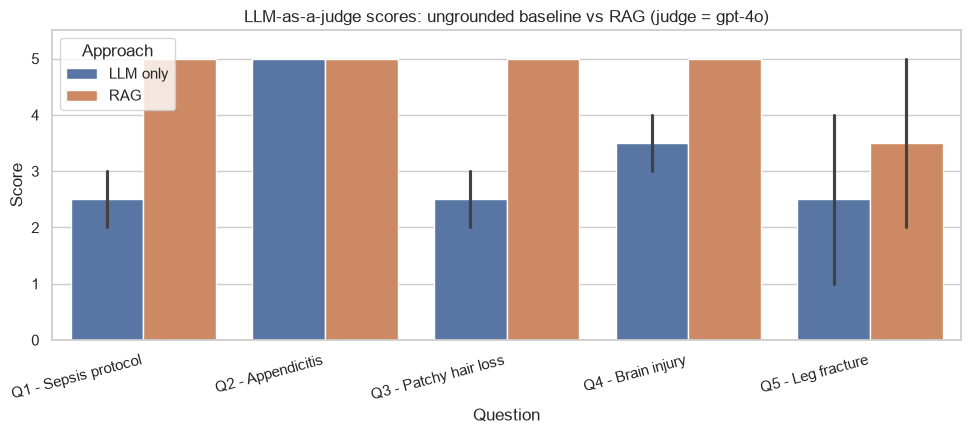

In [97]:
plot_df = evaluation_df.melt(
    id_vars=["Question", "Approach"], value_vars=["groundedness", "relevance"],
    var_name="Metric", value_name="Score",
)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=plot_df, x="Question", y="Score", hue="Approach", ax=ax)
ax.set_ylim(0, 5.5)
ax.set_title("LLM-as-a-judge scores: ungrounded baseline vs RAG (judge = gpt-4o)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


In [98]:
# Inspect a judge rationale in full to sanity-check that the scores are reasoned, not arbitrary
row = evaluation_df[(evaluation_df["Question"] == "Q5 - Leg fracture") & (evaluation_df["Approach"] == "RAG")].iloc[0]
print("Groundedness rationale\n" + "-" * 40)
show(row["groundedness_rationale"])
print("\nRelevance rationale\n" + "-" * 40)
show(row["relevance_rationale"])


Groundedness rationale
----------------------------------------
The answer correctly states that the information about precautions and treatment steps for a fractured leg
during a hiking trip is not covered in the provided context. The context primarily discusses snakebite
treatment and fall prevention, with no mention of fracture management. Therefore, the answer is fully grounded
in the context provided.

Score: 5

Relevance rationale
----------------------------------------
The question asks about precautions and treatment steps for a leg fracture during a hiking trip, as well as
considerations for care and recovery. The answer states that this information is not covered in the provided
medical manual, which is accurate given the context provided focuses on snake bites and falls, not fractures.
However, the answer does not address the second part of the question regarding care and recovery
considerations.

Score: 2


**Observations — what the separate `gpt-4o` judge actually did:**

| Question | LLM only G/R | RAG G/R |
| --- | --- | --- |
| Q1 Sepsis | 2 / 3 | **5 / 5** |
| Q2 Appendicitis | 5 / 5 | **5 / 5** |
| Q3 Hair loss | 2 / 3 | **5 / 5** |
| Q4 Brain injury | 3 / 4 | **5 / 5** |
| Q5 Leg fracture | 1 / 4 | 5 / 2 |
| Q5 + expansion | — | **4 / 4** |

- **RAG wins cleanly on groundedness** (mean **5.0 vs 2.6**). Unlike the Llama same-model judge, `gpt-4o` penalised the ungrounded baseline: Q1 scored 2, Q5 scored 1. Mean relevance is 4.4 (RAG) vs 3.8 (LLM only). The metric is actually measuring derivation-from-context here, which is the point of using a different judge.
- **Relevance tracks truncation and retrieval.** Baseline Q1 and Q3 are 3 (truncated mid-limb). Q2 baseline is 5 — this run named both procedures, so the judge treated it as complete. RAG Q1–Q4 score 5 (Q4 rehab as one sentence was enough this time). Q5 RAG is 2 because a correct abstention does not answer a hiking-fracture question. Expansion raises Q5 to **4 / 4** — the right direction and a larger lift than the previous 4 / 3.
- **Q2 baseline groundedness 5 is the remaining metric failure:** an unsourced (now complete) appendicitis answer was judged fully grounded against Chapter 11 context it never saw. Consistency with the context is still being rewarded for conventional medical content.
- **Q5 LLM-only relevance parsed as 4 this run** (the judge did emit `Score:`). The rubric says a multi-part question that is only partly answered must not score above 3; the printed answer still never left field care (truncates during bleeding control), so 4 is generous.
- Groundedness and relevance still cannot certify retrieval precision. Q5 RAG's 5/2 is a well-grounded abstention from snakebite context. The chapter-level report is the required third metric.


---
## 8. Actionable Insights and Business Recommendations


### 8.1 What the Prototype Demonstrates

A retrieval-augmented assistant built on the Merck Manual and `gpt-4o-mini`, with a separate `gpt-4o` judge, answers real clinical questions with **source-traceable, manual-specific detail** that the same model cannot produce unaided.

| | Ungrounded LLM | Prompt-engineered LLM | RAG (`k=3`) | RAG + constrained expansion (Q5) |
| --- | --- | --- | --- | --- |
| Clinical specificity | Textbook outline; 256 tokens reached 30 mL/kg and named appendectomy, still missed Merck endpoints | Well structured; JAK inhibitors appear from pre-training | CVP/PAOP endpoints, McBurney's / Rovsing / psoas / obturator, diphencyprone | Splint, ice, compartment syndrome, fat embolism, 3–4 week immobilisation limit |
| Verifiability | None | None | Chapter and page | Chapter 323 at rank 1 |
| Multi-part coverage | All 5 truncated at 256 tokens (Q2 named both procedures; Q4 reached rehab) | 3 of 5 complete | 4 of 5 on-topic; Q5 abstains | Q5 on-topic; trail/evacuation limb still missing |
| Mean groundedness (gpt-4o) | **2.6** | not scored | **5.0** | 4 |
| Mean relevance (gpt-4o) | 3.8 | not scored | **4.4** | 4 |
| Main failure mode | Truncation + unverifiable | Structure makes unsourced claims look authoritative | Wrong-chapter retrieval; generator abstains | Expansion quality; neighbouring rehab/falls chunks |

The business implication is that the bottleneck shifts. With a bare LLM the constraint is *knowledge and token budget*; with RAG the constraint is *retrieval quality*. That is a far better problem to have. Using a hosted model does not change it — it only removes the local VRAM / `n_ctx` constraint and, in this run, made abstention actually fire.


### 8.2 Key Findings

1. **Grounding, not model size, drives clinical usefulness.** `gpt-4o-mini` with the right three chunks outperformed the same model answering from memory on every question where retrieval worked. Q1 went from a Surviving-Sepsis-style 30 mL/kg outline (truncated mid-antibiotics) to CVP/PAOP endpoints and a dopamine dose threshold. A stronger hosted generator does not replace retrieval; it follows the retrieved text more faithfully.

2. **Abstention worked on this model.** For the hiking-fracture question, `k=3` similarity retrieved snakebite and falls passages. `gpt-4o-mini` returned the mandatory "I don't know" string rather than rewriting snakebite care as fracture care or answering from pre-training. That is the failure mode the Llama 7B notebook did not contain. **Sources must still be shown on every answer**, because an abstention without a source list looks like a broken assistant, and a wrong-chapter answer in a weaker model would look like a working one.

3. **The root cause was vocabulary, not `k`.** A general-purpose embedding mapped "hiking trip" nearer to wilderness first aid than to fractures. A weak expansion (`leg fracture management precautions treatment recovery care`) still missed Chapter 323. A constrained rewrite that named anatomy and indexed interventions put Chapter 323 at rank 1. H3's hand-written query remains the ceiling (3 of 3 chunks).

4. **Tuning levers are non-monotonic.** Halving chunk size cut Q1 context cost 41% and broke MMR on Q5. `k=2` matched `k=3` on appendicitis; `k=6` was wasteful on hair loss and necessary (with MMR) for fractures. Every configuration can produce a fluent answer, including a fluent abstention. Chapter-level provenance is the tuning signal.

5. **Prompt engineering and RAG solve different problems.** Structure finished alopecia (JAK ladder) and made appendicitis headings explicit; the 256-token baseline already named both appendectomy techniques. RAG replaced generic signs with McBurney's / Rovsing / psoas / obturator, and replaced JAK inhibitors with the manual's corticosteroid / anthralin / contact-immunotherapy ladder. Combination 3's JAK inhibitors are a **currency gap**: the hosted model knows therapies the 19th-edition corpus does not contain.

6. **A separate judge is necessary and, here, actually discriminating.** `gpt-4o` scored RAG groundedness 5.0 vs 2.6 for the baseline and gave Q1 baseline a 2. That is a larger, more honest gap than the Llama self-judge. It still awarded Q2 baseline a groundedness 5, so it is not a complete quality gate. Retrieval precision remains a third metric.

7. **Index-build correctness is a first-order concern.** This run reused `medical_manual_db` because vector count already equalled chunk count (4,657). Rebuilding without that check would have appended. The assertion is the only thing that makes that failure loud.


### 8.3 Recommendations

**Immediate (days, no infrastructure change)**
1. **Show sources on every answer** — chapter and page. This run's Q5 abstention is only interpretable because the source table showed Bites & Stings.
2. **Deploy constrained clinical query expansion.** One extra ~60-token call, with anatomy + indexed interventions and no setting words, moved Q5 from abstention to Chapter 323 at rank 1. Validate the rewrite before retrieving; the unconstrained first attempt failed.
3. **Default search type: MMR on the 1000/100 index, `k` 4–6 for multi-part or descriptive questions, `k=2` where one chapter obviously matches.** Do not combine MMR with the 500/50 index on this corpus.
4. **Assert index integrity** — vector count equals chunk count — before serving.
5. **Keep decoding near-greedy (`temperature` ≤ 0.2)** and keep the abstention rule. On `gpt-4o-mini` the rule fired; treat that as model-specific, not guaranteed.
6. **Add a retrieval-score threshold before generation.** Abstention worked here; a similarity floor would have skipped generation entirely on H0.

**Near term (weeks)**
7. **Evaluate a biomedical embedding model** against `bge-base-en-v1.5`. Finding 3 says the residual errors live in lay-to-clinical synonymy.
8. **Add a cross-encoder re-ranker** (retrieve 20, keep 4). Addresses Chapter 323 arriving at rank 8, Chapter 172 occupying a TBI slot, and three Rehabilitation chunks crowding the expanded Q5.
9. **Add hybrid retrieval (BM25 + dense).** A lexical match on "fracture" would have rescued H0.
10. **Build a labelled evaluation set** of 50–100 clinician-written triples and track precision@k alongside groundedness. Keep the judge on a different model from the generator.

**Strategic (quarters)**
11. **Human-in-the-loop by design.** Decision support with mandatory clinician review and captured sources.
12. **Expand the corpus** with dated guideline updates. Combination 3 volunteered JAK inhibitors the 19th edition does not contain.
13. **Extract figures and tables explicitly.** Zero empty pages does not mean dosage tables inside pages are retrievable.
14. **Plan for governance:** API cost budgets (unlike a local GGUF, every token is billed), PHI handling, and revalidation whenever the manual, embedding model, or LLM is updated.


### 8.4 Expected Business Impact

- **Time saved per query:** minutes of manual searching reduced to seconds, with the source page cited for verification.
- **Standardisation of care:** every clinician is answered from the same authoritative text.
- **Cost profile:** `gpt-4o-mini` plus a `gpt-4o` judge avoids GPU operations, at per-token API cost and with data leaving the organisation. For a prototype this is the right trade; for a clinical pilot, a private endpoint should be on the table.
- **Adoption risk:** concentrated in retrieval quality, expansion quality, and source transparency. This run showed the generator will abstain when asked; it will not fix a wrong chapter on its own.

---

### Conclusion

The prototype answers the project's core question affirmatively: a RAG pipeline over the Merck Manual turns a general-purpose chat model into a source-traceable clinical reference. On four of five questions at `k=3` it produced manual-specific detail — resuscitation endpoints, named examination signs, a corticosteroid/contact-immunotherapy ladder — that the same model could not produce unaided. On the fifth it abstained rather than invent, which is the correct behaviour given the retrieved context.

The remaining risk is not in the language model. It is in the retriever's ability to bridge the language patients use to the language the manual is written in. A weak query rewrite still missed the fractures chapter; a constrained rewrite put it at rank 1. Index-integrity assertions, a separate judge, mandatory source display, and constrained expansion address the failures this notebook actually observed. A biomedical embedding, a cross-encoder re-ranker, a retrieval-score abstention threshold, and a labelled retrieval benchmark with clinician review are the prerequisites for any clinical pilot.


<font size=6 color='blue'>Power Ahead</font>

___
